# AI Carbon Footprint Calculator — Model Training Notebook

This notebook covers data cleaning, EDA, feature engineering, preprocessing, model training, and export.

## 1. Imports & Setup

In [1]:
import ast
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use('dark_background')
sns.set_palette("viridis")

pd.set_option("display.max_columns", None)

MODELS_DIR = "../models"
DATA_DIR = "../data"


## 2. Load Raw Data

In [2]:
df = pd.read_csv(f"{DATA_DIR}/carbon_emission.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (10000, 20)


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [3]:
print("Missing values per column (raw):")
print(df.isna().sum()[df.isna().sum() > 0])


Missing values per column (raw):
Vehicle Type    6721
dtype: int64


## 3. Data Cleaning

### 3A. Vehicle Type — fill blank/NaN with 'None'

Vehicle Type is blank when Transport is `public` or `walk/bicycle` (no vehicle used).

In [4]:
df['Vehicle Type'] = df['Vehicle Type'].fillna("None")
df['Vehicle Type'] = df['Vehicle Type'].replace(r'^\s*$', "None", regex=True)
print(df['Vehicle Type'].value_counts())


Vehicle Type
None        6721
lpg          697
electric     671
petrol       647
hybrid       642
diesel       622
Name: count, dtype: int64


### 3B. Recycling — parse stringified lists into binary columns

In [5]:
def parse_list_str(val):
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
        return []
    except (ValueError, SyntaxError):
        return []

df['Recycling_parsed'] = df['Recycling'].apply(parse_list_str)

recycling_types = sorted({item for lst in df['Recycling_parsed'] for item in lst})
print("Unique recycling types found:", recycling_types)

for r_type in recycling_types:
    col_name = f"Recycling_{r_type}"
    df[col_name] = df['Recycling_parsed'].apply(lambda lst: 1 if r_type in lst else 0)

df = df.drop(columns=['Recycling', 'Recycling_parsed'])
print("New Recycling_* columns:", [c for c in df.columns if c.startswith('Recycling_')])


Unique recycling types found: ['Glass', 'Metal', 'Paper', 'Plastic']
New Recycling_* columns: ['Recycling_Glass', 'Recycling_Metal', 'Recycling_Paper', 'Recycling_Plastic']


### 3C. Cooking_With — parse stringified lists into binary columns

In [6]:
df['Cooking_With_parsed'] = df['Cooking_With'].apply(parse_list_str)

cooking_types = sorted({item for lst in df['Cooking_With_parsed'] for item in lst})
print("Unique cooking appliance types found:", cooking_types)

for c_type in cooking_types:
    col_name = f"Cooking_{c_type}"
    df[col_name] = df['Cooking_With_parsed'].apply(lambda lst: 1 if c_type in lst else 0)

df = df.drop(columns=['Cooking_With', 'Cooking_With_parsed'])
print("New Cooking_* columns:", [c for c in df.columns if c.startswith('Cooking_')])


Unique cooking appliance types found: ['Airfryer', 'Grill', 'Microwave', 'Oven', 'Stove']
New Cooking_* columns: ['Cooking_Airfryer', 'Cooking_Grill', 'Cooking_Microwave', 'Cooking_Oven', 'Cooking_Stove']


### 3D. Verify cleaning — zero NaNs remain

In [7]:
remaining_nans = df.isna().sum().sum()
print(f"Total remaining NaN values: {remaining_nans}")
assert remaining_nans == 0, "There are still NaN values in the dataframe!"

print("\nShape:", df.shape)
print("\nDtypes:\n", df.dtypes)
df.head()


Total remaining NaN values: 0

Shape: (10000, 27)

Dtypes:
 Body Type                        object
Sex                              object
Diet                             object
How Often Shower                 object
Heating Energy Source            object
Transport                        object
Vehicle Type                     object
Social Activity                  object
Monthly Grocery Bill              int64
Frequency of Traveling by Air    object
Vehicle Monthly Distance Km       int64
Waste Bag Size                   object
Waste Bag Weekly Count            int64
How Long TV PC Daily Hour         int64
How Many New Clothes Monthly      int64
How Long Internet Daily Hour      int64
Energy efficiency                object
CarbonEmission                    int64
Recycling_Glass                   int64
Recycling_Metal                   int64
Recycling_Paper                   int64
Recycling_Plastic                 int64
Cooking_Airfryer                  int64
Cooking_Grill       

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,CarbonEmission,Recycling_Glass,Recycling_Metal,Recycling_Paper,Recycling_Plastic,Cooking_Airfryer,Cooking_Grill,Cooking_Microwave,Cooking_Oven,Cooking_Stove
0,overweight,female,pescatarian,daily,coal,public,None,often,230,frequently,210,large,4,7,26,1,No,2238,0,1,0,0,0,0,0,1,1
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,None,often,114,rarely,9,extra large,3,9,38,5,No,1892,0,1,0,0,0,0,1,0,1
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,2595,0,1,0,0,0,0,1,1,0
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,None,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,1074,1,1,1,1,1,1,1,0,0
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,4743,0,0,1,0,0,0,0,1,0


### 3E. Save cleaned dataframe

In [8]:
df.to_csv(f"{DATA_DIR}/carbon_emission_cleaned.csv", index=False)
print(f"Saved cleaned dataset to {DATA_DIR}/carbon_emission_cleaned.csv")


Saved cleaned dataset to ../data/carbon_emission_cleaned.csv


## 4. Exploratory Data Analysis (EDA)

All EDA below uses the cleaned dataframe.

### 4.1 Dataset Overview

In [9]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescribe:")
display(df.describe())
print("\nRemaining nulls:", df.isna().sum().sum())


Shape: (10000, 27)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      10000 non-null  object
 1   Sex                            10000 non-null  object
 2   Diet                           10000 non-null  object
 3   How Often Shower               10000 non-null  object
 4   Heating Energy Source          10000 non-null  object
 5   Transport                      10000 non-null  object
 6   Vehicle Type                   10000 non-null  object
 7   Social Activity                10000 non-null  object
 8   Monthly Grocery Bill           10000 non-null  int64 
 9   Frequency of Traveling by Air  10000 non-null  object
 10  Vehicle Monthly Distance Km    10000 non-null  int64 
 11  Waste Bag Size                 10000 non-null  object
 12  Waste Bag Weekly Count         1000

,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission,Recycling_Glass,Recycling_Metal,Recycling_Paper,Recycling_Plastic,Cooking_Airfryer,Cooking_Grill,Cooking_Microwave,Cooking_Oven,Cooking_Stove
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000,10000.000000
mean,173.875200,2031.485900,4.024600,12.139200,25.109000,11.889100,2269.147300,0.497900,0.504700,0.49770,0.499700,0.499200,0.499200,0.507300,0.505,0.504100
std,72.234018,2769.715597,1.990375,7.106369,14.698725,7.277218,1017.675247,0.500021,0.500003,0.50002,0.500025,0.500024,0.500024,0.499972,0.500,0.500008
min,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,306.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000
25%,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000,1538.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000
50%,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000,2080.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000,1.000000
75%,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000,2768.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000,1.000000
max,299.000000,9999.000000,7.000000,24.000000,50.000000,24.000000,8377.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000,1.000000



Remaining nulls:

 0


### 4.2 Target Variable Distribution — CarbonEmission

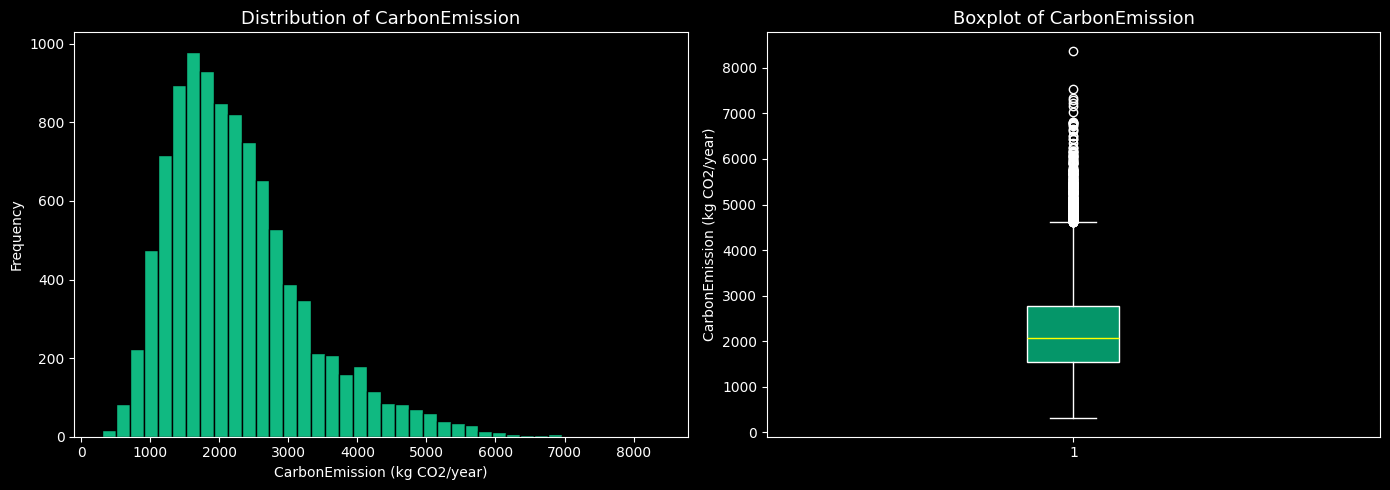

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['CarbonEmission'], bins=40, color='#10B981', edgecolor='black')
axes[0].set_title("Distribution of CarbonEmission", fontsize=13)
axes[0].set_xlabel("CarbonEmission (kg CO2/year)")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df['CarbonEmission'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#059669', color='white'),
                 medianprops=dict(color='yellow'))
axes[1].set_title("Boxplot of CarbonEmission", fontsize=13)
axes[1].set_ylabel("CarbonEmission (kg CO2/year)")

plt.tight_layout()
plt.show()


### 4.3 Correlation Heatmap (numeric columns)

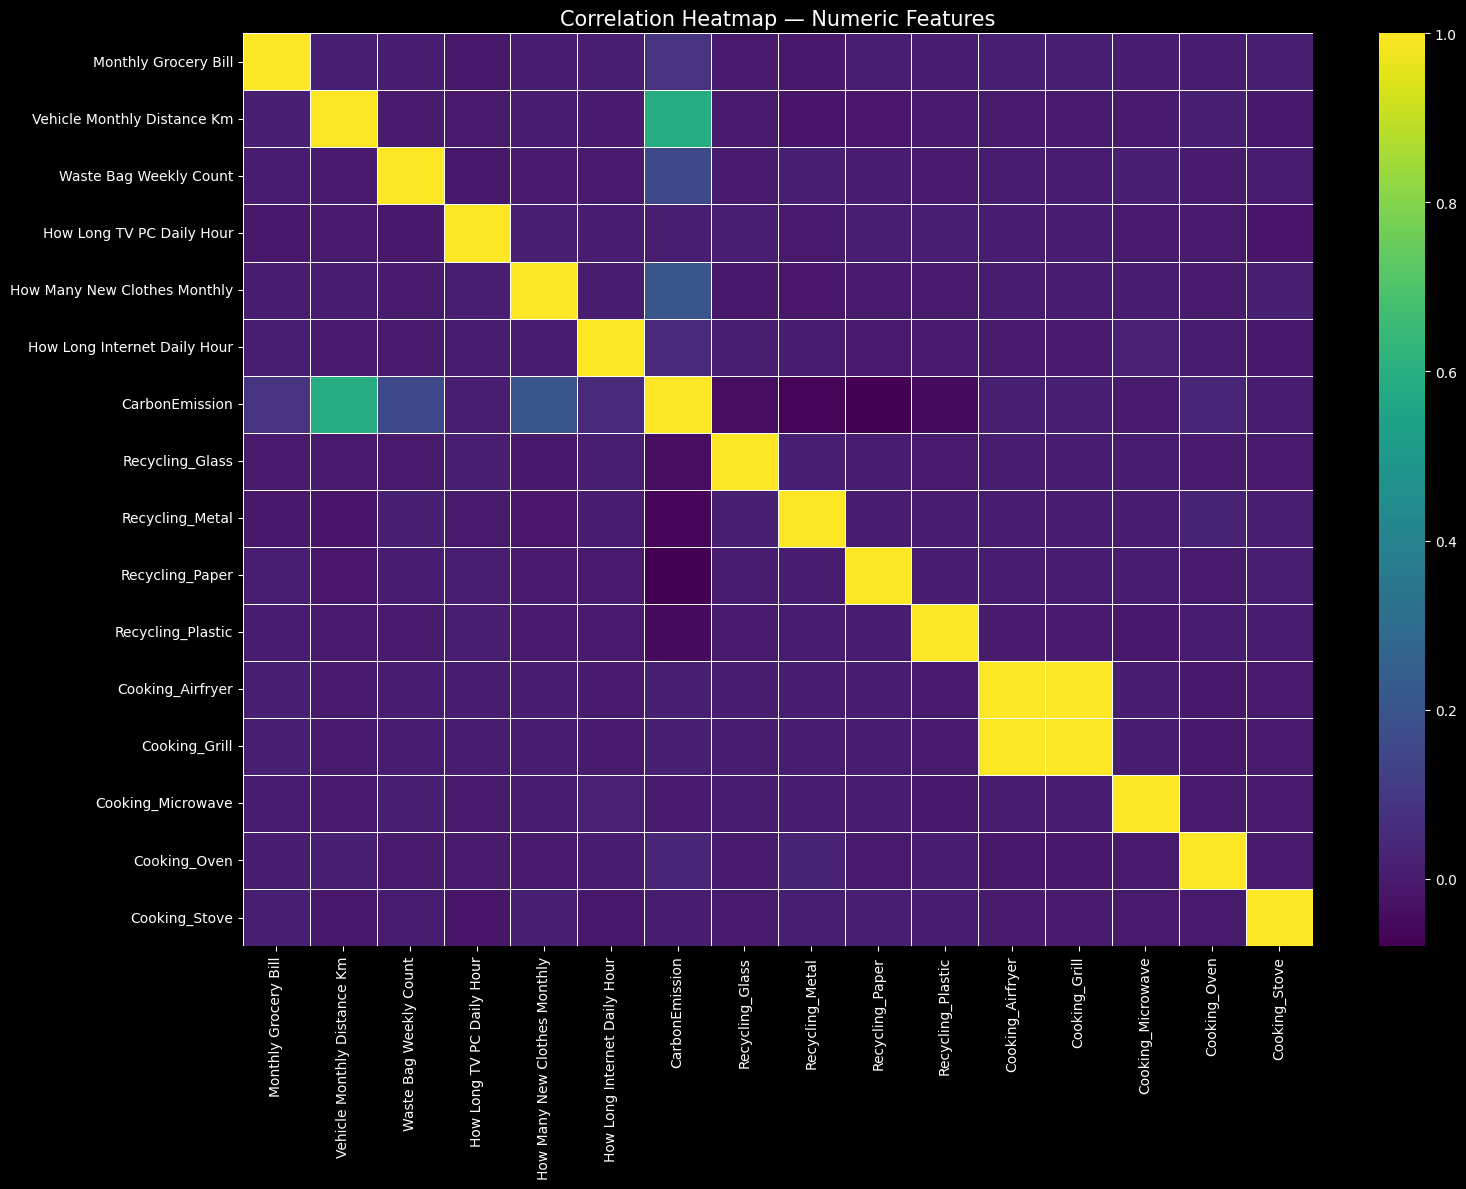

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='viridis', annot=False, linewidths=0.4, cbar=True)
plt.title("Correlation Heatmap — Numeric Features", fontsize=15)
plt.tight_layout()
plt.show()


### 4.4 Average CarbonEmission by Category — Bar Charts

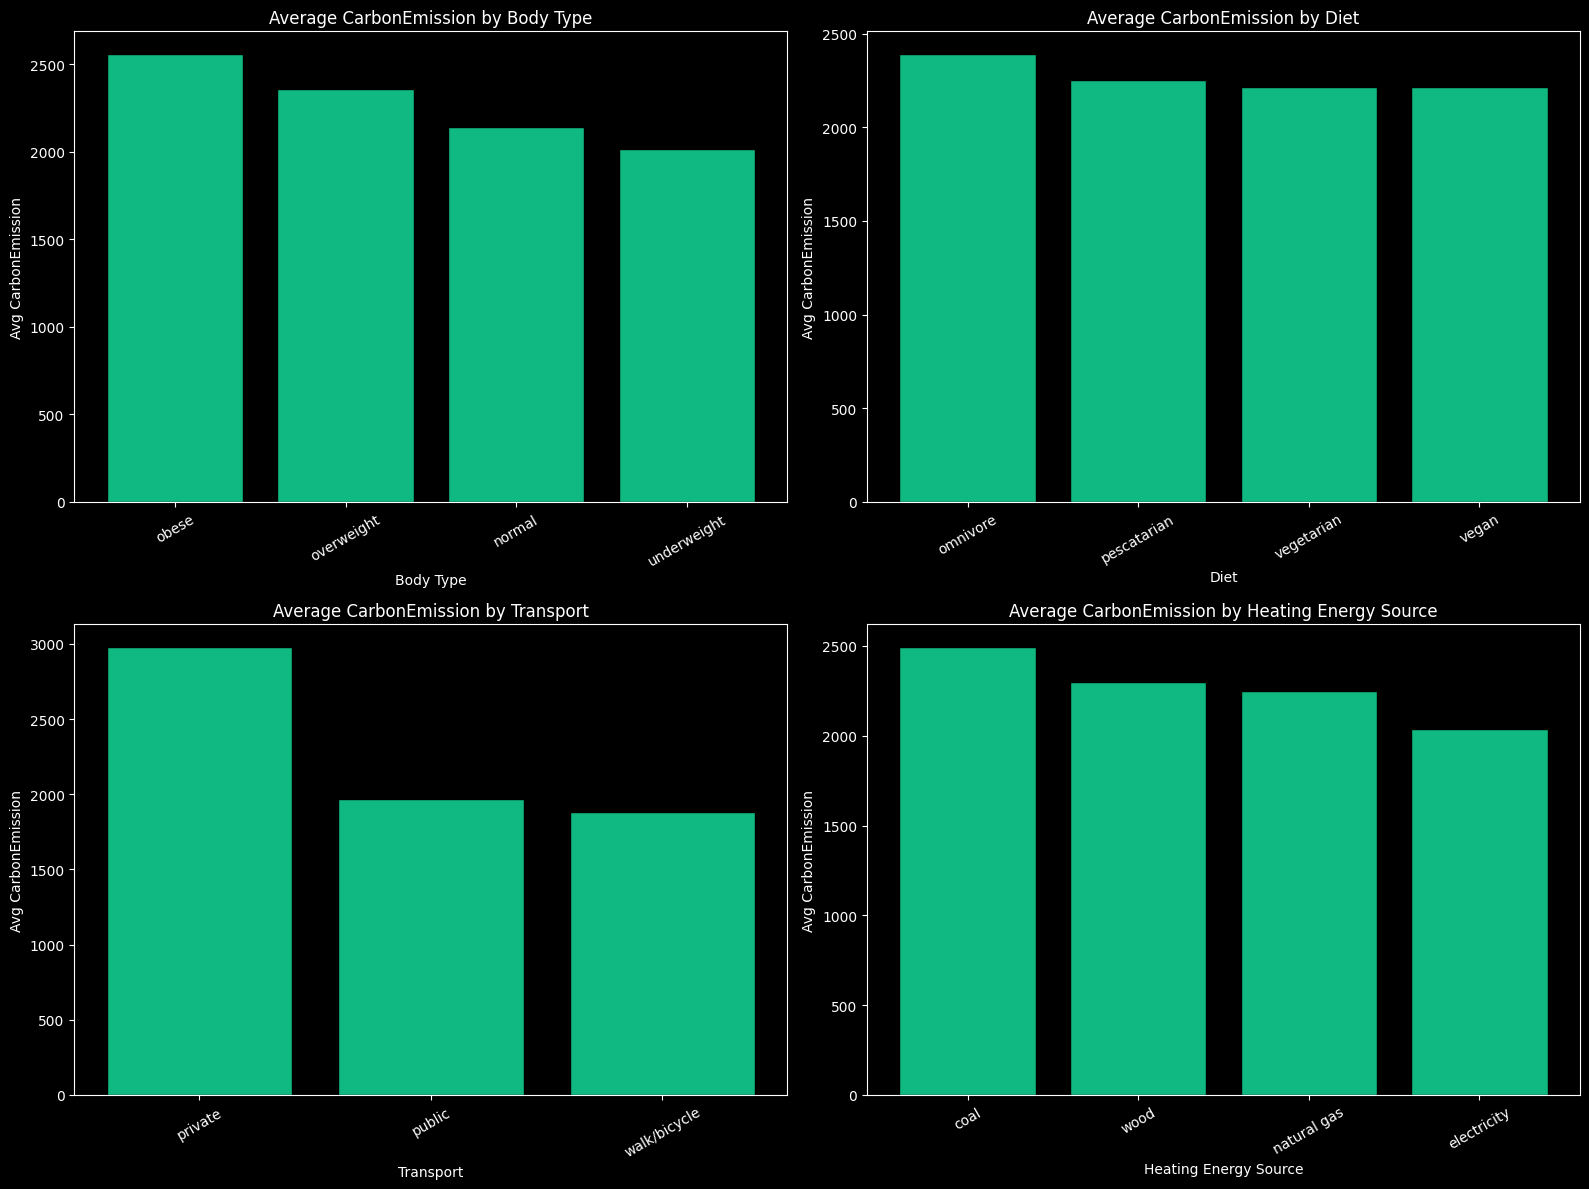

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

group_cols = ['Body Type', 'Diet', 'Transport', 'Heating Energy Source']
for ax, col in zip(axes.flat, group_cols):
    means = df.groupby(col)['CarbonEmission'].mean().sort_values(ascending=False)
    ax.bar(means.index, means.values, color='#10B981', edgecolor='black')
    ax.set_title(f"Average CarbonEmission by {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Avg CarbonEmission")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 4.5 CarbonEmission Box Plots by Category

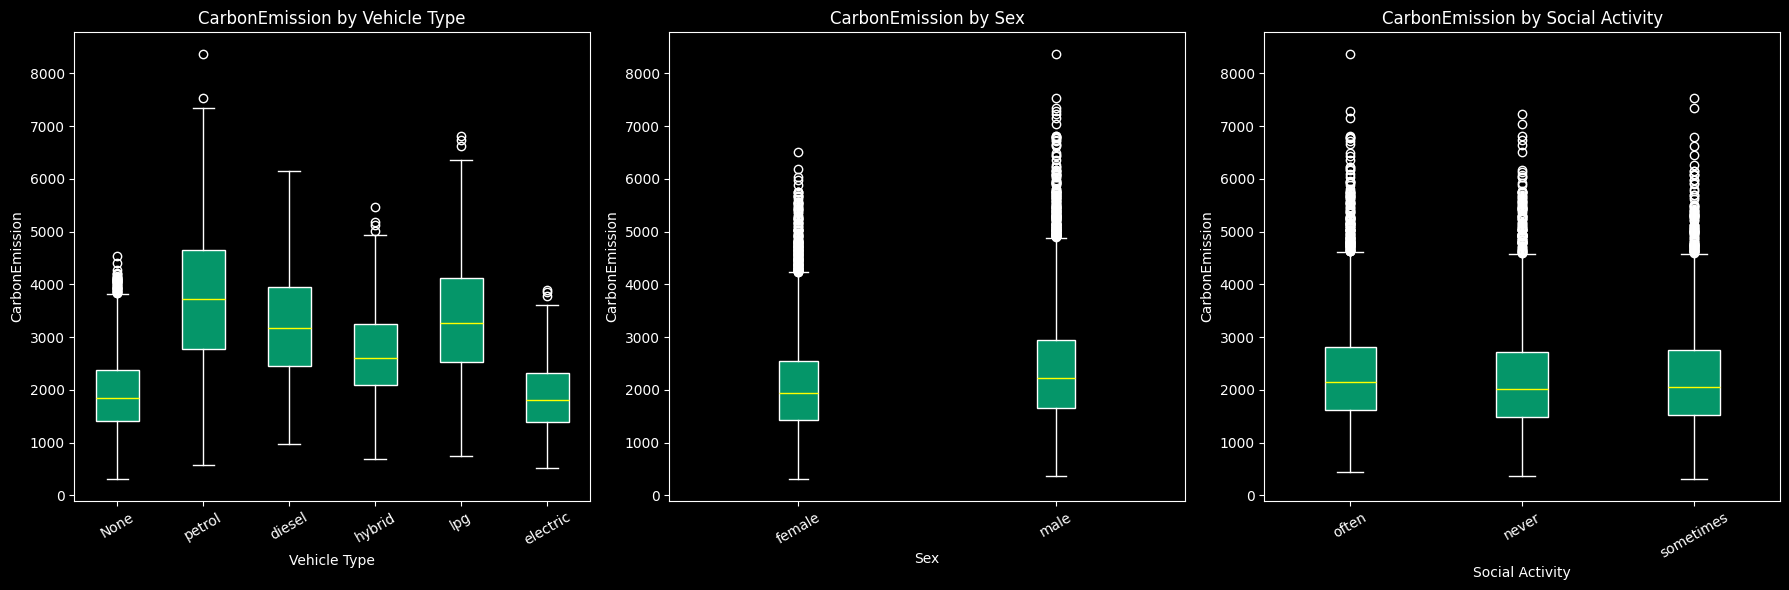

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

box_cols = ['Vehicle Type', 'Sex', 'Social Activity']
for ax, col in zip(axes, box_cols):
    categories = df[col].unique()
    data_by_cat = [df.loc[df[col] == cat, 'CarbonEmission'] for cat in categories]
    ax.boxplot(data_by_cat, labels=categories, patch_artist=True,
               boxprops=dict(facecolor='#059669', color='white'),
               medianprops=dict(color='yellow'))
    ax.set_title(f"CarbonEmission by {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("CarbonEmission")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 4.6 Scatter Plots

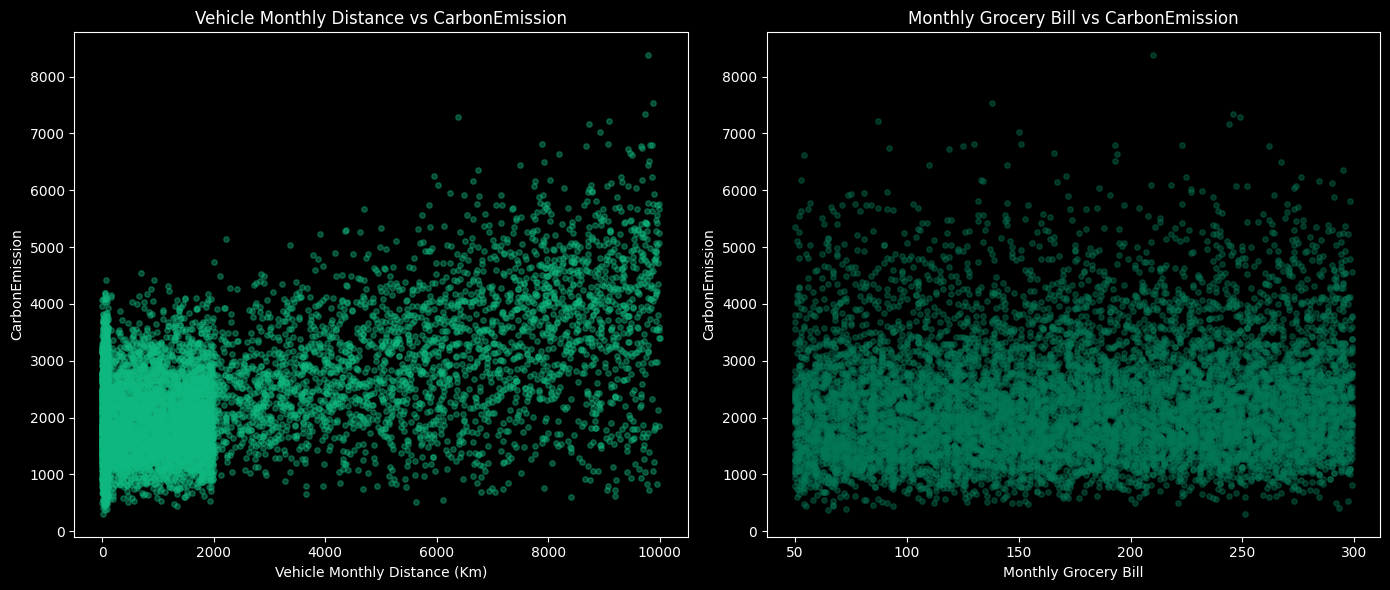

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df['Vehicle Monthly Distance Km'], df['CarbonEmission'],
                alpha=0.4, color='#10B981', s=15)
axes[0].set_title("Vehicle Monthly Distance vs CarbonEmission", fontsize=12)
axes[0].set_xlabel("Vehicle Monthly Distance (Km)")
axes[0].set_ylabel("CarbonEmission")

axes[1].scatter(df['Monthly Grocery Bill'], df['CarbonEmission'],
                alpha=0.4, color='#047857', s=15)
axes[1].set_title("Monthly Grocery Bill vs CarbonEmission", fontsize=12)
axes[1].set_xlabel("Monthly Grocery Bill")
axes[1].set_ylabel("CarbonEmission")

plt.tight_layout()
plt.show()


### 4.7 Diet Distribution — Pie Chart

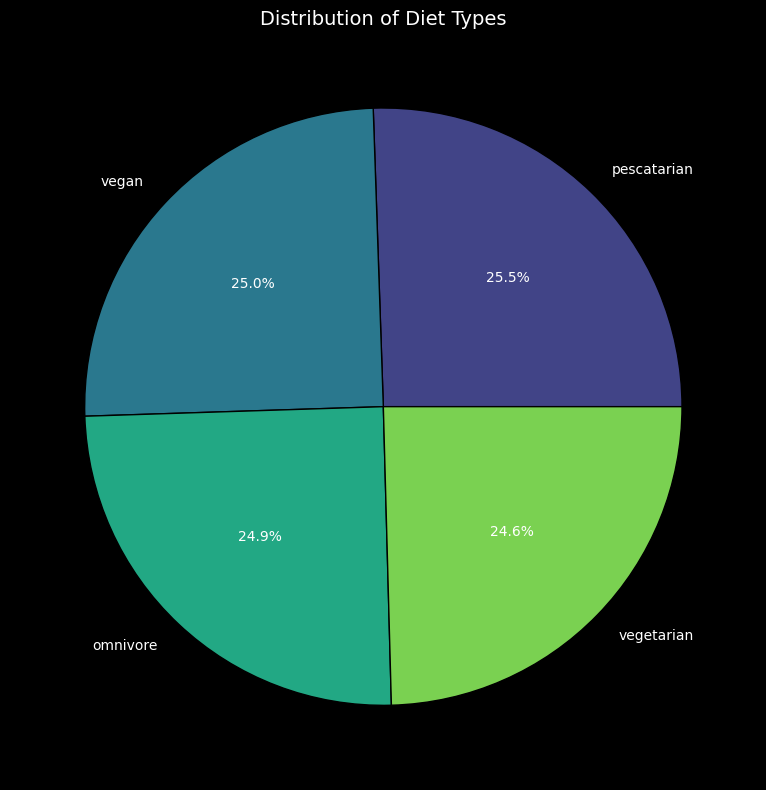

In [15]:
diet_counts = df['Diet'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(diet_counts.values, labels=diet_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette("viridis", len(diet_counts)),
        wedgeprops=dict(edgecolor='black'))
plt.title("Distribution of Diet Types", fontsize=14)
plt.tight_layout()
plt.show()


### 4.8 Top 10 Features Correlated with CarbonEmission

In [16]:
target_corr = corr['CarbonEmission'].drop('CarbonEmission').abs().sort_values(ascending=False)
print("Top 10 features correlated with CarbonEmission:")
print(target_corr.head(10))


Top 10 features correlated with CarbonEmission:
Vehicle Monthly Distance Km     0.594171
How Many New Clothes Monthly    0.198887
Waste Bag Weekly Count          0.159193
Monthly Grocery Bill            0.081587
Recycling_Paper                 0.079582
Recycling_Metal                 0.069098
Recycling_Plastic               0.046440
Recycling_Glass                 0.044160
How Long Internet Daily Hour    0.043878
Cooking_Oven                    0.032518
Name: CarbonEmission, dtype: float64


## 5. Feature Engineering

In [17]:
# Reload the cleaned CSV to keep this section runnable independently of Phase 1.
# keep_default_na=False prevents pandas from reinterpreting the literal string
# "None" (our Vehicle Type placeholder) as a missing value on reload.
df = pd.read_csv(f"{DATA_DIR}/carbon_emission_cleaned.csv", keep_default_na=False, na_values=[])
print("Loaded cleaned data:", df.shape)
print("Remaining nulls after reload:", df.isna().sum().sum())


Loaded cleaned data: (10000, 27)
Remaining nulls after reload: 0


In [18]:
# Total_Screen_Time
df['Total_Screen_Time'] = df['How Long TV PC Daily Hour'] + df['How Long Internet Daily Hour']

# Waste_Score
waste_bag_map = {'small': 1, 'medium': 2, 'large': 3, 'extra large': 4}
df['Waste_Score'] = df['Waste Bag Weekly Count'] * df['Waste Bag Size'].map(waste_bag_map)

# Green_Score = sum of all Recycling_ binary columns
recycling_cols = [c for c in df.columns if c.startswith('Recycling_')]
df['Green_Score'] = df[recycling_cols].sum(axis=1)

# Travel_Impact
vehicle_impact_map = {'petrol': 2.3, 'diesel': 2.7, 'hybrid': 1.5, 'lpg': 1.8, 'electric': 0.5, 'None': 0}
df['Travel_Impact'] = df['Vehicle Monthly Distance Km'] * df['Vehicle Type'].map(vehicle_impact_map).fillna(0)

# Shopping_Impact
df['Shopping_Impact'] = df['How Many New Clothes Monthly'] * 10

print(df[['Total_Screen_Time', 'Waste_Score', 'Green_Score', 'Travel_Impact', 'Shopping_Impact']].describe())


       Total_Screen_Time   Waste_Score   Green_Score  Travel_Impact  \
count       10000.000000  10000.000000  10000.000000   10000.000000   
mean           24.028300     10.079800      2.000000    2928.927990   
std            10.205984      7.101259      1.009506    5688.263073   
min             0.000000      1.000000      0.000000       0.000000   
25%            17.000000      4.000000      1.000000       0.000000   
50%            24.000000      8.000000      2.000000       0.000000   
75%            31.000000     15.000000      3.000000    3052.975000   
max            48.000000     28.000000      4.000000   26997.300000   

       Shopping_Impact  
count     10000.000000  
mean        251.090000  
std         146.987253  
min           0.000000  
25%         130.000000  
50%         250.000000  
75%         380.000000  
max         500.000000  


## 6. Label Encoding of Categorical Columns

In [19]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source',
    'Transport', 'Vehicle Type', 'Social Activity', 'Frequency of Traveling by Air',
    'Waste Bag Size', 'Energy efficiency',
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    file_name = f"le_{col.replace(' ', '_')}.pkl"
    joblib.dump(le, f"{MODELS_DIR}/{file_name}")
    print(f"Saved encoder: {file_name}  classes={list(le.classes_)}")


Saved encoder: le_Body_Type.pkl  classes=['normal', 'obese', 'overweight', 'underweight']
Saved encoder: le_Sex.pkl  classes=['female', 'male']
Saved encoder: le_Diet.pkl  classes=['omnivore', 'pescatarian', 'vegan', 'vegetarian']
Saved encoder: le_How_Often_Shower.pkl  classes=['daily', 'less frequently', 'more frequently', 'twice a day']
Saved encoder: le_Heating_Energy_Source.pkl  classes=['coal', 'electricity', 'natural gas', 'wood']
Saved encoder: le_Transport.pkl  classes=['private', 'public', 'walk/bicycle']
Saved encoder: le_Vehicle_Type.pkl  classes=['None', 'diesel', 'electric', 'hybrid', 'lpg', 'petrol']
Saved encoder: le_Social_Activity.pkl  classes=['never', 'often', 'sometimes']
Saved encoder: le_Frequency_of_Traveling_by_Air.pkl  classes=['frequently', 'never', 'rarely', 'very frequently']
Saved encoder: le_Waste_Bag_Size.pkl  classes=['extra large', 'large', 'medium', 'small']


Saved encoder: le_Energy_efficiency.pkl  classes=['No', 'Sometimes', 'Yes']


## 7. Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['CarbonEmission'])
y = df['CarbonEmission']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (8000, 31)  X_test: (2000, 31)


## 8. Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

joblib.dump(scaler, f"{MODELS_DIR}/scaler.pkl")
print("Saved scaler.pkl")


Saved scaler.pkl


In [22]:
print("Final feature list ({} features):".format(len(X.columns)))
print(list(X.columns))
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Final feature list (31 features):
['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill', 'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'Energy efficiency', 'Recycling_Glass', 'Recycling_Metal', 'Recycling_Paper', 'Recycling_Plastic', 'Cooking_Airfryer', 'Cooking_Grill', 'Cooking_Microwave', 'Cooking_Oven', 'Cooking_Stove', 'Total_Screen_Time', 'Waste_Score', 'Green_Score', 'Travel_Impact', 'Shopping_Impact']

X_train shape: (8000, 31)
X_test shape: (2000, 31)


## 9. Model Training

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42),
    "Linear Regression": LinearRegression(),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Random Forest


Trained: XGBoost
Trained: Linear Regression


## 10. Model Evaluation

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


results = {}
for name, model in trained_models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mape = mean_absolute_percentage_error(y_test, test_pred)

    results[name] = {
        "R2_train": r2_train, "R2_test": r2_test,
        "MAE": mae, "RMSE": rmse, "MAPE": mape,
    }

    print(f"\n--- {name} ---")
    print(f"R2 (train): {r2_train:.4f}   R2 (test): {r2_test:.4f}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

results_df = pd.DataFrame(results).T
results_df



--- Random Forest ---
R2 (train): 0.9896   R2 (test): 0.9275
MAE:  204.53
RMSE: 274.62
MAPE: 9.68%

--- XGBoost ---
R2 (train): 0.9976   R2 (test): 0.9825
MAE:  95.22
RMSE: 134.90
MAPE: 4.31%

--- Linear Regression ---
R2 (train): 0.7015   R2 (test): 0.6987
MAE:  468.35
RMSE: 559.66
MAPE: 24.05%


,R2_train,R2_test,MAE,RMSE,MAPE
Random Forest,0.989590,0.927464,204.527443,274.619595,9.682959
XGBoost,0.997619,0.982496,95.215744,134.902649,4.306850
Linear Regression,0.701463,0.698742,468.352074,559.660757,24.049595


### 10.1 Model Comparison Bar Chart

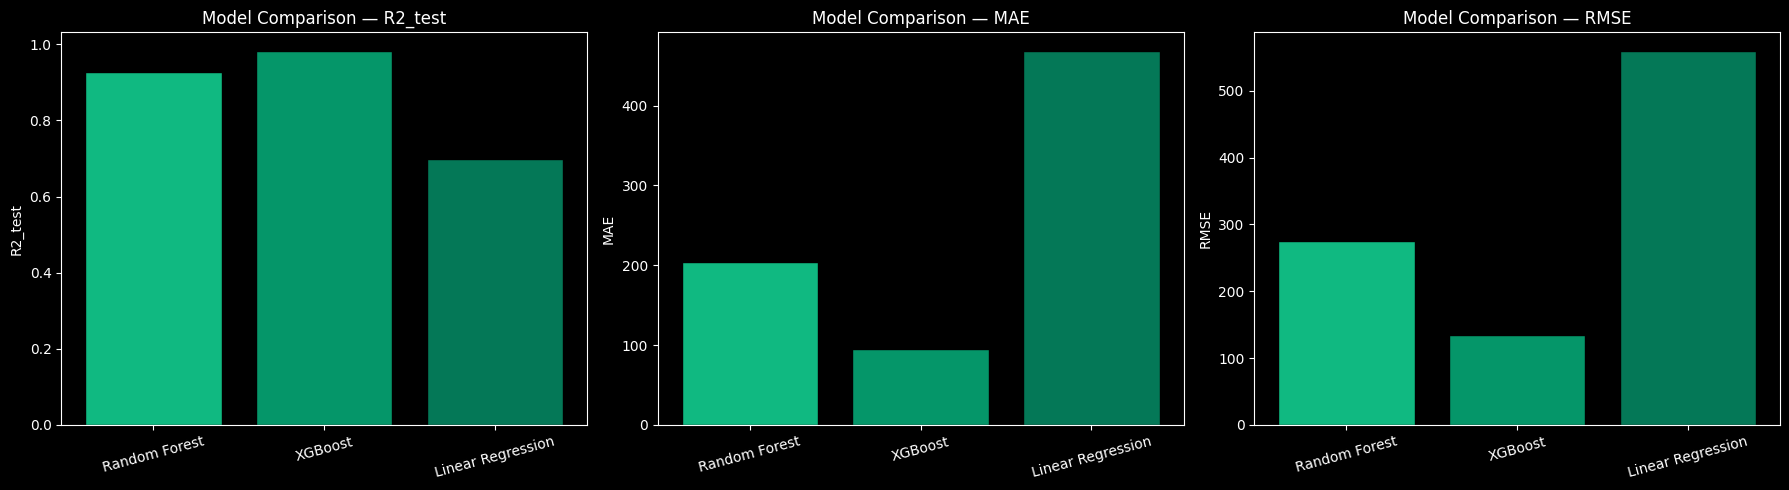

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['R2_test', 'MAE', 'RMSE']
colors = ['#10B981', '#059669', '#047857']

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(results_df.index, results_df[metric], color=colors, edgecolor='black')
    ax.set_title(f"Model Comparison — {metric}", fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### 10.2 Best Model Diagnostics

In [26]:
best_model_name = results_df['R2_test'].idxmax()
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name} (R2_test={results_df.loc[best_model_name, 'R2_test']:.4f})")


Best model: XGBoost (R2_test=0.9825)


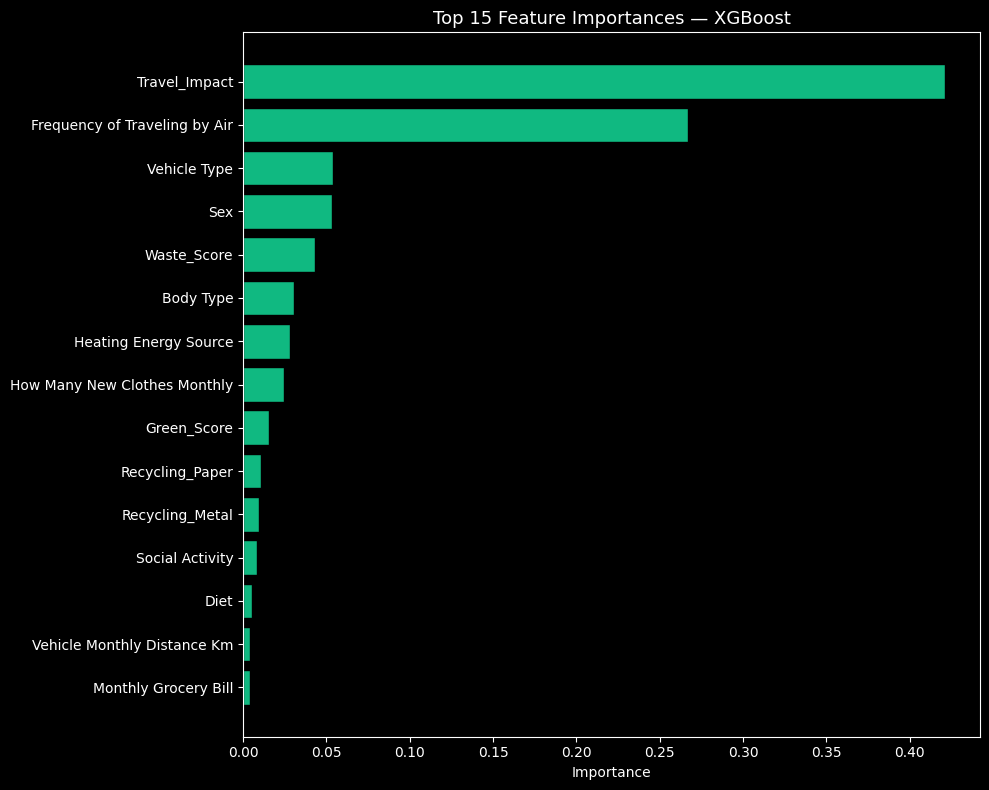

In [27]:
# Feature importance (top 15) — only for tree-based models
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top15 = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    plt.barh(top15.index[::-1], top15.values[::-1], color='#10B981', edgecolor='black')
    plt.title(f"Top 15 Feature Importances — {best_model_name}", fontsize=13)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no feature_importances_ attribute (e.g. Linear Regression).")


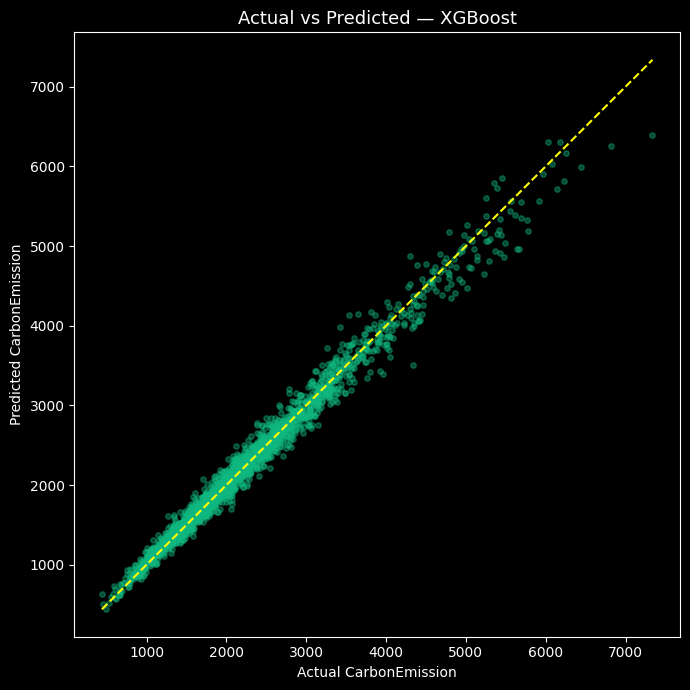

In [28]:
best_test_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_test_pred, alpha=0.4, color='#10B981', s=15)
lims = [min(y_test.min(), best_test_pred.min()), max(y_test.max(), best_test_pred.max())]
plt.plot(lims, lims, color='yellow', linestyle='--')
plt.title(f"Actual vs Predicted — {best_model_name}", fontsize=13)
plt.xlabel("Actual CarbonEmission")
plt.ylabel("Predicted CarbonEmission")
plt.tight_layout()
plt.show()


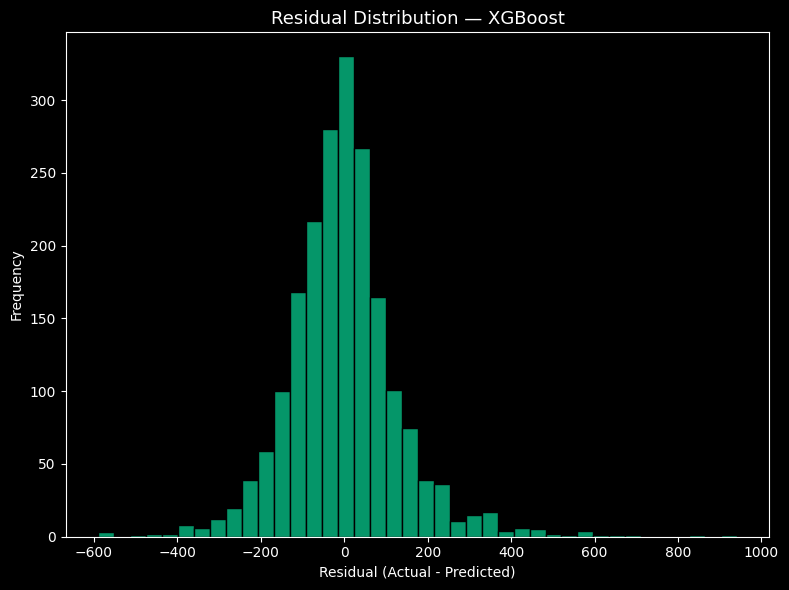

In [29]:
residuals = y_test - best_test_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=40, color='#059669', edgecolor='black')
plt.title(f"Residual Distribution — {best_model_name}", fontsize=13)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 11. KMeans Clustering — User Segments

In [30]:
from sklearn.cluster import KMeans

X_all_scaled = pd.concat([X_train_scaled, X_test_scaled])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_all_scaled)

# Compute mean CarbonEmission per cluster to rank & name them
all_y = pd.concat([y_train, y_test])
cluster_df = pd.DataFrame({'cluster': cluster_ids, 'CarbonEmission': all_y.values})
cluster_means = cluster_df.groupby('cluster')['CarbonEmission'].mean().sort_values()

ordered_names = ["Eco Warrior", "Green Beginner", "Average Consumer", "High Emitter"]
cluster_labels = {cluster_id: ordered_names[rank] for rank, cluster_id in enumerate(cluster_means.index)}

print("Cluster mean CarbonEmission (ascending):")
print(cluster_means)
print("\nCluster label mapping:", cluster_labels)

joblib.dump(kmeans, f"{MODELS_DIR}/kmeans_model.pkl")
joblib.dump(cluster_labels, f"{MODELS_DIR}/cluster_labels.pkl")
print("Saved kmeans_model.pkl and cluster_labels.pkl")


Cluster mean CarbonEmission (ascending):
cluster
3    1786.386873
1    1907.204241
2    2132.695925
0    3206.386606
Name: CarbonEmission, dtype: float64

Cluster label mapping: {3: 'Eco Warrior', 1: 'Green Beginner', 2: 'Average Consumer', 0: 'High Emitter'}
Saved kmeans_model.pkl and cluster_labels.pkl


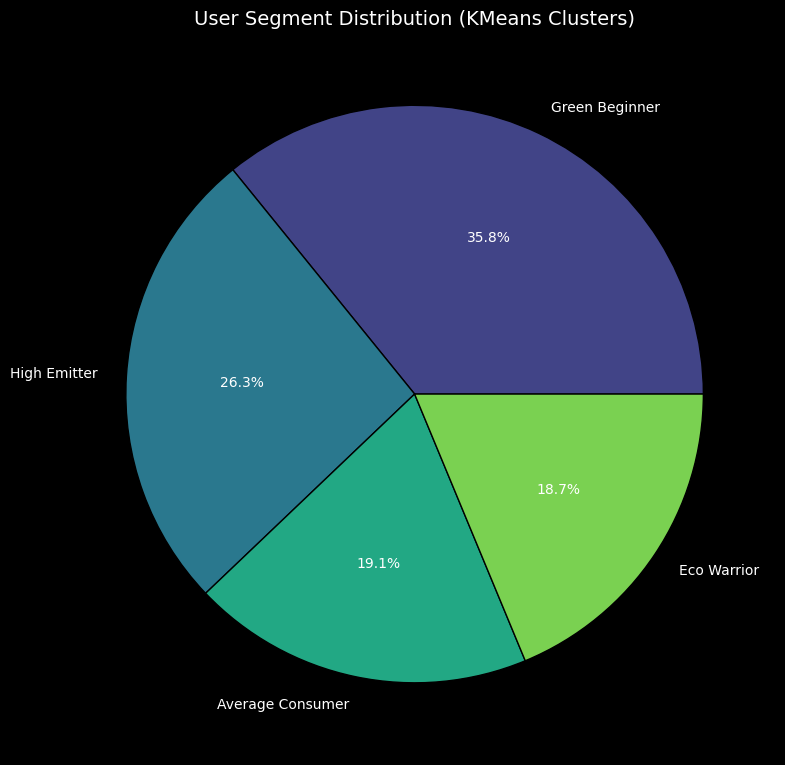

In [31]:
cluster_df['segment'] = cluster_df['cluster'].map(cluster_labels)
segment_counts = cluster_df['segment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette("viridis", len(segment_counts)),
        wedgeprops=dict(edgecolor='black'))
plt.title("User Segment Distribution (KMeans Clusters)", fontsize=14)
plt.tight_layout()
plt.show()


## 12. Export Best Model & Feature Names

In [32]:
joblib.dump(best_model, f"{MODELS_DIR}/carbon_model.pkl")
joblib.dump(list(X.columns), f"{MODELS_DIR}/feature_names.pkl")
print(f"Saved carbon_model.pkl (best model: {best_model_name})")
print("Saved feature_names.pkl")


Saved carbon_model.pkl (best model: XGBoost)
Saved feature_names.pkl


## 13. Summary

In [33]:
import os

print(f"Best model: {best_model_name}")
print(f"R2 score (test): {results_df.loc[best_model_name, 'R2_test']:.4f}")

pkl_files = [f for f in os.listdir(MODELS_DIR) if f.endswith('.pkl')]
print(f"\nTotal .pkl files saved in models/ folder: {len(pkl_files)}")
for f in sorted(pkl_files):
    print(" -", f)


Best model: XGBoost
R2 score (test): 0.9825

Total .pkl files saved in models/ folder: 16
 - carbon_model.pkl
 - cluster_labels.pkl
 - feature_names.pkl
 - kmeans_model.pkl
 - le_Body_Type.pkl
 - le_Diet.pkl
 - le_Energy_efficiency.pkl
 - le_Frequency_of_Traveling_by_Air.pkl
 - le_Heating_Energy_Source.pkl
 - le_How_Often_Shower.pkl
 - le_Sex.pkl
 - le_Social_Activity.pkl
 - le_Transport.pkl
 - le_Vehicle_Type.pkl
 - le_Waste_Bag_Size.pkl
 - scaler.pkl
